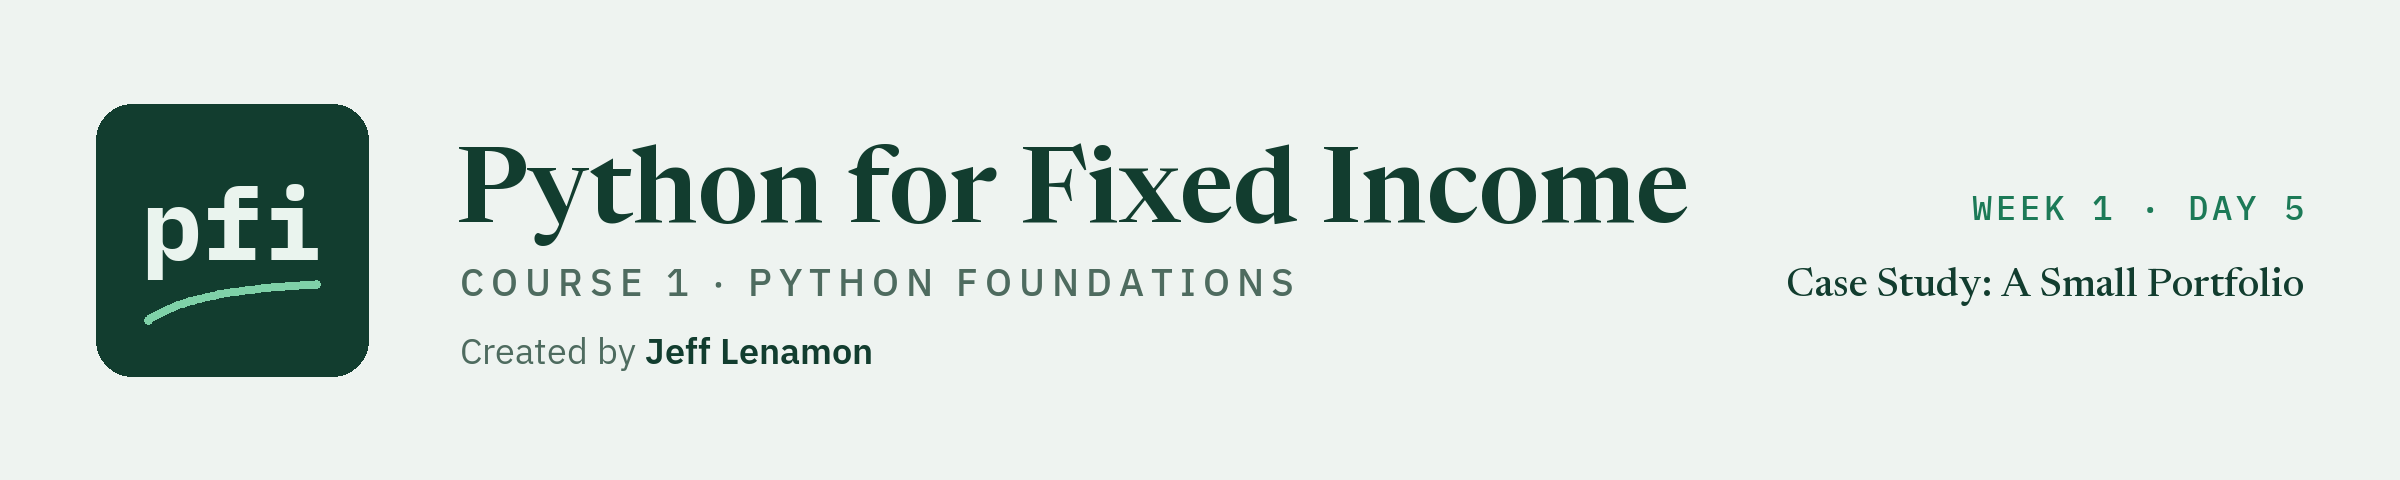

# Case Study: Organizing a Small Portfolio

Week 1. One job from start to finish, using everything from the week.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week1/day5/05_case_study_a_small_portfolio.ipynb)

## Problem Definition

### Context

A credit desk has just taken over a small portfolio of six corporate bonds from another team. The handover was an email with the holdings typed into the body. There is no file and no system record. Before anyone can analyze the portfolio, its records have to be put in order.

### Objective

You are the desk's analyst. Your job is to store the holdings in a form that makes it easy to:

* look up everything about one bond,
* update a bond when its rating or price changes,
* answer simple questions about the portfolio, and
* hand the data on in a structure built for analysis.

### The data

The email listed six bonds. The issuers are invented.

| Ticker | Issuer | Sector | Rating | Score | Coupon (%) | Price | Face held |
| --- | --- | --- | --- | --- | --- | --- | --- |
| QVNE | Quorvane Energy | Energy | BBB | 9 | 5.25 | 98.50 | 1,500,000 |
| DNMR | Dunmarrow Rail | Transportation | BB+ | 11 | 6.125 | 103.25 | 500,000 |
| PLWK | Pellwick Paper | Materials | A- | 7 | 4.75 | 95.00 | 750,000 |
| HLVF | Halvering Foods | Consumer | B+ | 14 | 7.50 | 101.00 | 250,000 |
| OSTV | Ostrevale Telecom | Telecom | BBB- | 10 | 5.75 | 99.00 | 1,000,000 |
| VYRH | Veyrholt Health | Health Care | BB | 12 | 6.75 | 102.50 | 400,000 |

The score puts ratings in order: AAA is 1 and each notch lower adds one. A score of 10 or lower is investment grade. A score of 11 or higher is high yield.

### How we will solve it

We start with the simplest way to store the data and improve it one step at a time, moving on each time the current way becomes awkward. That is how real code usually grows.

## 1.0 Organizing the Data

### 1.1 Storing bonds as variables

Let's start by storing the ticker of the first bond in a variable.

In [1]:
# a variable named ticker holds the value 'QVNE'
ticker = 'QVNE'
print('The ticker of the first bond is', ticker)

The ticker of the first bond is QVNE


That works. Let's store the other tickers the same way.

In [2]:
# one variable for each ticker
ticker1 = 'QVNE'
ticker2 = 'DNMR'
ticker3 = 'PLWK'
ticker4 = 'HLVF'
ticker5 = 'OSTV'
ticker6 = 'VYRH'

**A reminder about variable names**

* A name must start with a letter or an underscore, never a number.
* A name can contain only letters, numbers, and underscores.
* Names are case-sensitive: `price`, `Price`, and `PRICE` are three different variables.

Six variables for one column of the table, and there are six more columns. A portfolio of 200 bonds would need over a thousand variables. This is not a workable way to store data.

What if we store each column as a list?

### 1.2 Organizing and querying the data

**A reminder about lists**

* A list is an ordered group of items stored in one variable.
* It is written with square brackets, with commas between the items.

In [3]:
# all six tickers in one list
ticker_list = ['QVNE', 'DNMR', 'PLWK', 'HLVF', 'OSTV', 'VYRH']

# print the list to check it
print('Tickers:', ticker_list)

Tickers: ['QVNE', 'DNMR', 'PLWK', 'HLVF', 'OSTV', 'VYRH']


* One variable now holds the whole column.
* Let's create a list for the sector, rating score, coupon, price, and face held.

In [4]:
sector_list = ['Energy', 'Transportation', 'Materials', 'Consumer', 'Telecom', 'Health Care']
score_list = [9, 11, 7, 14, 10, 12]
coupon_list = [5.25, 6.125, 4.75, 7.5, 5.75, 6.75]
price_list = [98.5, 103.25, 95.0, 101.0, 99.0, 102.5]
face_list = [1500000, 500000, 750000, 250000, 1000000, 400000]

In [5]:
# print every list
print('Tickers:', ticker_list)
print('Sectors:', sector_list)
print('Scores:', score_list)
print('Coupons:', coupon_list)
print('Prices:', price_list)
print('Face held:', face_list)

Tickers: ['QVNE', 'DNMR', 'PLWK', 'HLVF', 'OSTV', 'VYRH']
Sectors: ['Energy', 'Transportation', 'Materials', 'Consumer', 'Telecom', 'Health Care']
Scores: [9, 11, 7, 14, 10, 12]
Coupons: [5.25, 6.125, 4.75, 7.5, 5.75, 6.75]
Prices: [98.5, 103.25, 95.0, 101.0, 99.0, 102.5]
Face held: [1500000, 500000, 750000, 250000, 1000000, 400000]


The lists are in place. Now let's fetch some data.

**Get all the details of the bond whose ticker is DNMR.**

The six lists are in the same order, so a bond sits at the same position in every list. First we need that position. The list method `index()` returns the position of a value.

In [6]:
# find the position of 'DNMR' in the list of tickers
pos = ticker_list.index('DNMR')
print(pos)

1


* DNMR is at index 1. Positions start at 0, so index 1 is the second item.

In [7]:
# use the same position in every list
print(ticker_list[pos])
print(sector_list[pos])
print(score_list[pos])
print(coupon_list[pos])
print(price_list[pos])
print(face_list[pos])

DNMR
Transportation
11
6.125
103.25
500000


We can now pull a full record for any bond.

**Excel side by side.** This is the `MATCH` and `INDEX` pair. `=MATCH("DNMR", A2:A7, 0)` finds the row, as `index()` does. `=INDEX(E2:E7, row)` then reads another column at that row, as `coupon_list[pos]` does.

News arrives: OSTV has been downgraded one notch, from BBB- to BB+. Its score moves from 10 to 11. Let's update the record.

In [8]:
# find the position of OSTV
pos = ticker_list.index('OSTV')
# assign the new score at that position
score_list[pos] = 11
# print the list to check
score_list

[9, 11, 7, 14, 11, 12]

* The fifth score is now 11. OSTV has crossed from investment grade to high yield.

**Predict 1**

Instead of one list per column, we could store one record per bond:

```
bond_a = ['QVNE', 9, 98.5]     # ticker, score, price
bond_b = ('DNMR', 11, 103.25)  # ticker, score, price
```

Both bonds are marked up by a quarter point, and we update the price in each record:

```
bond_a[2] = 98.75
bond_b[2] = 103.5
```

What do you expect to happen?

> A) An error on the first update, because there is a problem with the list.
>
> B) An error on the second update, because that record is not a list.
>
> C) No error. Both prices are updated.

Decide, then run the cell.

In [9]:
bond_a = ['QVNE', 9, 98.5]     # ticker, score, price
bond_b = ('DNMR', 11, 103.25)  # ticker, score, price

bond_a[2] = 98.75
print(bond_a)
bond_b[2] = 103.5
print(bond_b)

['QVNE', 9, 98.75]


TypeError: 'tuple' object does not support item assignment

* The answer is B. The first record uses square brackets, so it is a list, and its price was updated. The second uses round brackets, so it is a tuple, and a tuple cannot be changed.
* Data that must be updated belongs in a list.

### 1.3 Updating data based on conditions

The pricing service sends a correction: every **high yield** price it supplied was half a point too high. Investment grade prices were correct. We need to take 0.5 off the price of each bond with a score of 11 or higher.

A change that applies only to some bonds needs a conditional statement.

**A reminder about if and else**

```
if condition:
    code to run when the condition is true
else:
    code to run when it is false
```

Let's apply the correction to the first two bonds.

In [10]:
# the first bond is at index 0
if score_list[0] >= 11:
    price_list[0] = price_list[0] - 0.5
    print('Price corrected for', ticker_list[0])
else:
    print('Price unchanged for', ticker_list[0])

# the second bond is at index 1
if score_list[1] >= 11:
    price_list[1] = price_list[1] - 0.5
    print('Price corrected for', ticker_list[1])
else:
    print('Price unchanged for', ticker_list[1])

Price unchanged for QVNE
Price corrected for DNMR


In [11]:
price_list

[98.5, 102.75, 95.0, 101.0, 99.0, 102.5]

* QVNE is investment grade, so its price stayed at 98.5. DNMR is high yield, so its price dropped from 103.25 to 102.75.

That took a block of code per bond, with only the index changing. For six bonds it is tedious, and for 200 it is hopeless. Let's put the prices back to how they arrived and do this properly.

In [12]:
# restore the prices from the email
price_list = [98.5, 103.25, 95.0, 101.0, 99.0, 102.5]

**A reminder about the for loop**

```
for item in sequence:
    code to repeat
```

`range(len(ticker_list))` produces every index of the list, however long the list is.

In [13]:
for i in range(len(ticker_list)):
    if score_list[i] >= 11:
        price_list[i] = price_list[i] - 0.5
        print('Price corrected for', ticker_list[i])
    else:
        print('Price unchanged for', ticker_list[i])

Price unchanged for QVNE
Price corrected for DNMR
Price unchanged for PLWK
Price corrected for HLVF
Price corrected for OSTV
Price corrected for VYRH


In [14]:
price_list

[98.5, 102.75, 95.0, 100.5, 98.5, 102.0]

* Four bonds were corrected and two were left alone. OSTV was corrected because its downgrade made it high yield.
* The same six lines would handle 200 bonds without a single change.

Now let's ask the portfolio some questions.

**How many bonds are investment grade?**

In [15]:
# start a counter at zero
count = 0

for i in range(len(ticker_list)):
    if score_list[i] <= 10:
        # add one to the counter each time the condition is true
        count = count + 1

print('Number of investment grade bonds:', count)

Number of investment grade bonds: 2


* Two: QVNE and PLWK.

**Excel side by side.** In Excel this is one function: `=COUNTIF(D2:D7, "<=10")`. The loop does the same job, and unlike `COUNTIF` it can do anything else we like to each matching row while it is there.

**How many bonds trade above par?**

In [16]:
count = 0

for i in range(len(ticker_list)):
    if price_list[i] > 100:
        count = count + 1

print('Number of bonds above par:', count)

Number of bonds above par: 3


**How many bonds are investment grade, and how many are high yield?**

In [17]:
# two counters this time
investment_grade = 0
high_yield = 0

for i in range(len(ticker_list)):
    if score_list[i] <= 10:
        investment_grade = investment_grade + 1
    else:
        high_yield = high_yield + 1

print('Investment grade:', investment_grade)
print('High yield:', high_yield)

Investment grade: 2
High yield: 4


**Print all the information about HLVF.**

In [18]:
for i in range(len(ticker_list)):
    if ticker_list[i] == 'HLVF':
        print('----------------------------------')
        print('Ticker:', ticker_list[i])
        print('Sector:', sector_list[i])
        print('Score:', score_list[i])
        print('Coupon:', coupon_list[i])
        print('Price:', price_list[i])
        print('Face held:', face_list[i])
        print('----------------------------------')

----------------------------------
Ticker: HLVF
Sector: Consumer
Score: 14
Coupon: 7.5
Price: 100.5
Face held: 250000
----------------------------------


**Predict 2**

The desk wants to count the bonds that are high yield **and also** trade above par. The code below has a blank:

```
count = 0
for i in range(len(ticker_list)):
    if score_list[i] >= 11 ___ price_list[i] > 100:
        count = count + 1
```

Which word belongs in the blank: `and` or `or`? And what will the count be?

Decide, then run the cell. It tries both.

In [19]:
count_and = 0
count_or = 0

for i in range(len(ticker_list)):
    # 'and' is true only when both conditions are true
    if score_list[i] >= 11 and price_list[i] > 100:
        count_and = count_and + 1
    # 'or' is true when at least one condition is true
    if score_list[i] >= 11 or price_list[i] > 100:
        count_or = count_or + 1

print('With and:', count_and)
print('With or:', count_or)

With and: 3
With or: 4


* The word is `and`, and the count is 3: DNMR, HLVF, and VYRH.
* With `or` the count is 4, because OSTV is high yield but trades below par. `or` lets in a bond that passes either test.

**A reminder about the while loop**

```
while condition:
    code to repeat
```

**Predict 3**

The desk has three trades waiting to settle:

```
trades_to_settle = 3
while trades_to_settle > 0:
    print('Settling a trade...')
    trades_to_settle = trades_to_settle - 1
print('All trades settled')
```

How many times will 'Settling a trade...' be printed? Decide, then run the cell.

In [20]:
trades_to_settle = 3
while trades_to_settle > 0:
    print('Settling a trade...')
    trades_to_settle = trades_to_settle - 1
print('All trades settled')

Settling a trade...
Settling a trade...
Settling a trade...
All trades settled


* Three times. Each pass takes one off the counter, and the loop stops when the counter reaches 0. The last line is not indented, so it runs once, after the loop has finished.

### 1.4 A modular way of fetching data

The block that printed everything about HLVF works, but to look up another bond we would have to copy it and change the ticker. Copying code is how mistakes spread.

Let's use a function.

**A reminder about functions**

* A function is a named block of code that does one job.
* It lets us reuse the code by calling the name.

```
def function_name(arguments):
    code
    return result
```

In [21]:
# def starts a function definition, followed by the name and the arguments
def bond_info(ticker):
    """
    Print everything the desk knows
    about one bond.
    """
    # find the position of the ticker
    pos = ticker_list.index(ticker)
    print('----------------------------------')
    print('Ticker:', ticker_list[pos])
    print('Sector:', sector_list[pos])
    print('Score:', score_list[pos])
    print('Coupon:', coupon_list[pos])
    print('Price:', price_list[pos])
    print('Face held:', face_list[pos])
    print('----------------------------------')

**Print the details of QVNE.**

In [22]:
bond_info('QVNE')

----------------------------------
Ticker: QVNE
Sector: Energy
Score: 9
Coupon: 5.25
Price: 98.5
Face held: 1500000
----------------------------------


**Print the details of VYRH.**

In [23]:
bond_info('VYRH')

----------------------------------
Ticker: VYRH
Sector: Health Care
Score: 12
Coupon: 6.75
Price: 102.0
Face held: 400000
----------------------------------


* One line per lookup. If the layout ever needs to change, it changes in one place.

**Predict 4**

Here are two functions that fetch the coupon of a bond:

> Function 1
```
def coupon_printed(ticker):
    pos = ticker_list.index(ticker)
    print(coupon_list[pos])
```

> Function 2
```
def coupon_returned(ticker):
    pos = ticker_list.index(ticker)
    return coupon_list[pos]
```

Each is called the same way, and the result is stored and printed:

```
result = coupon_printed('QVNE')
print(result)
```

What does each version show? Decide, then run the two cells.

In [24]:
def coupon_printed(ticker):
    pos = ticker_list.index(ticker)
    print(coupon_list[pos])


result = coupon_printed('QVNE')
print(result)

5.25
None


In [25]:
def coupon_returned(ticker):
    pos = ticker_list.index(ticker)
    return coupon_list[pos]


result = coupon_returned('QVNE')
print(result)

5.25


* Function 1 shows 5.25 and then `None`. It printed the coupon to the screen but handed nothing back, so `result` is empty.
* Function 2 shows 5.25 once. It returned the value, so `result` holds 5.25 and can be used in a calculation.
* Use `return` whenever the answer is needed afterwards.

**Predict 5**

The desk wants a rating bucket for each bond. Two analysts each write a function:

> Function 1
```
def bucket_one(score):
    if score <= 7:
        label = 'A or better'
    elif score <= 10:
        label = 'BBB'
    else:
        label = 'High yield'
    return label
```

> Function 2
```
def bucket_two(score):
    if score <= 10:
        label = 'BBB'
    elif score <= 7:
        label = 'A or better'
    else:
        label = 'High yield'
    return label
```

PLWK is rated A-, a score of 7. What does each function return for it? Decide, then run the cell.

In [26]:
def bucket_one(score):
    if score <= 7:
        label = 'A or better'
    elif score <= 10:
        label = 'BBB'
    else:
        label = 'High yield'
    return label


def bucket_two(score):
    if score <= 10:
        label = 'BBB'
    elif score <= 7:
        label = 'A or better'
    else:
        label = 'High yield'
    return label


print('Function 1:', bucket_one(7))
print('Function 2:', bucket_two(7))

Function 1: A or better
Function 2: BBB


* Function 1 returns 'A or better'. Function 2 returns 'BBB', which is wrong.
* Python checks the conditions from the top and stops at the first one that is true. A score of 7 passes `score <= 10`, so Function 2 never reaches its second test. That second branch can never run.
* When conditions overlap, put the narrowest one first.

### 1.5 Combining all the data into a single element

The function made lookups easy, but the data is still spread over six separate lists. They are held together only by our promise to keep them in the same order. Nothing stops one list being sorted or edited without the others.

Let's combine them into one dictionary.

**A reminder about dictionaries**

* A dictionary stores data as key:value pairs.
* It is written with curly brackets.
* A value is looked up by its key.

In [27]:
# each key is a column name, and each value is the list for that column
portfolio = {
    'Ticker': ticker_list,
    'Sector': sector_list,
    'Score': score_list,
    'Coupon': coupon_list,
    'Price': price_list,
    'Face': face_list
}

In [28]:
# print the dictionary
portfolio

{'Ticker': ['QVNE', 'DNMR', 'PLWK', 'HLVF', 'OSTV', 'VYRH'],
 'Sector': ['Energy',
  'Transportation',
  'Materials',
  'Consumer',
  'Telecom',
  'Health Care'],
 'Score': [9, 11, 7, 14, 11, 12],
 'Coupon': [5.25, 6.125, 4.75, 7.5, 5.75, 6.75],
 'Price': [98.5, 102.75, 95.0, 100.5, 98.5, 102.0],
 'Face': [1500000, 500000, 750000, 250000, 1000000, 400000]}

**Get all the values under the key 'Ticker'.**

In [29]:
portfolio['Ticker']

['QVNE', 'DNMR', 'PLWK', 'HLVF', 'OSTV', 'VYRH']

**Get the third ticker.**

In [30]:
# pick the list by its key, then the item by its index
portfolio['Ticker'][2]

'PLWK'

**Get all the information about HLVF.**

HLVF is the fourth bond, at index 3. The dictionary method `items()` hands us each key together with its list, so we can read the item at index 3 from every list.

In [31]:
# key is the column name, value is the list for that column
for key, value in portfolio.items():
    print(key, value[3])

Ticker HLVF
Sector Consumer
Score 14
Coupon 7.5
Price 100.5
Face 250000


**Predict 6**

Instead of the column names, we could use the tickers as the keys:

```
by_ticker = {
    'QVNE': [9, 5.25, 98.5],
    'DNMR': [11, 6.125, 102.75],
    'PLWK': [7, 4.75, 95.0]
}

for key, value in by_ticker.items():
    print(key, value[1])
```

What will this print? Decide, then run the cell.

In [32]:
# each value holds score, coupon, price
by_ticker = {
    'QVNE': [9, 5.25, 98.5],
    'DNMR': [11, 6.125, 102.75],
    'PLWK': [7, 4.75, 95.0]
}

for key, value in by_ticker.items():
    print(key, value[1])

QVNE 5.25
DNMR 6.125
PLWK 4.75


* It prints each ticker with its coupon. The key is the ticker, and `value[1]` is the second item of that bond's list, which is the coupon.

The dictionary holds everything in one place. But the questions we asked earlier, such as counting the high yield bonds above par, would still need hand-written loops. For real analysis we want a structure that is organized like a table and can answer those questions directly.

That is what a **library** is for. A library is a collection of code someone else has written and tested, ready to be imported.

## 2.0 Getting the Data Into a Convenient Structure

**What is pandas?**

pandas is the standard Python library for working with data in tables. Its main structure is the **DataFrame**: rows and columns with names, like a worksheet, with a large set of tools for filtering, summarizing, and combining data. Most analysis in this course from here on uses it.

### 2.1 Converting the dictionary into a pandas DataFrame

pandas does not come with Python. It was installed when you set up the environment from `requirements.txt`. In Google Colab it is already installed.

Let's import it.

In [33]:
# import loads a library. 'as pd' gives it a short nickname, which is the usual convention.
import pandas as pd

Now let's create a DataFrame from the dictionary.

In [34]:
# pd.DataFrame builds a table from a dictionary of lists
df = pd.DataFrame(portfolio)

In [35]:
# show the DataFrame
df

,Ticker,Sector,Score,Coupon,Price,Face
0,QVNE,Energy,9,5.250,98.50,1500000
1,DNMR,Transportation,11,6.125,102.75,500000
2,PLWK,Materials,7,4.750,95.00,750000
3,HLVF,Consumer,14,7.500,100.50,250000
4,OSTV,Telecom,11,5.750,98.50,1000000
5,VYRH,Health Care,12,6.750,102.00,400000


* The keys of the dictionary became the column names, and each list became a column. pandas added a numbered index down the left side, starting at 0.
* The email has become a proper table.

**Excel side by side.** A DataFrame is a worksheet: named columns, numbered rows, one record per row. The difference is that every step that produced it is written down in code and can be run again tomorrow on a new email.

### 2.2 Accessing and analyzing the data

In [36]:
# the first 3 rows. With nothing in the brackets, head() shows the first 5.
df.head(3)

,Ticker,Sector,Score,Coupon,Price,Face
0,QVNE,Energy,9,5.250,98.50,1500000
1,DNMR,Transportation,11,6.125,102.75,500000
2,PLWK,Materials,7,4.750,95.00,750000


In [37]:
# the last 3 rows. With nothing in the brackets, tail() shows the last 5.
df.tail(3)

,Ticker,Sector,Score,Coupon,Price,Face
3,HLVF,Consumer,14,7.50,100.5,250000
4,OSTV,Telecom,11,5.75,98.5,1000000
5,VYRH,Health Care,12,6.75,102.0,400000


In [38]:
# shape gives the number of rows and the number of columns
df.shape

(6, 6)

* 6 rows and 6 columns: six bonds, six attributes.

In [39]:
# info() lists each column with its data type and how many values it holds
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ticker  6 non-null      str    
 1   Sector  6 non-null      str    
 2   Score   6 non-null      int64  
 3   Coupon  6 non-null      float64
 4   Price   6 non-null      float64
 5   Face    6 non-null      int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 420.0 bytes


* Every column has 6 values, so nothing is missing.
* The score and face are whole numbers (`int64`). The coupon and price have decimals (`float64`). The ticker and sector are text, which pandas shows as `str`, or as `object` in older versions.

A statistical summary takes one line.

In [40]:
# describe() summarizes every numeric column
df.describe()

,Score,Coupon,Price,Face
count,6.000000,6.000000,6.000000,6.000000e+00
mean,10.666667,6.020833,99.541667,7.333333e+05
std,2.422120,1.001301,2.830268,4.600725e+05
min,7.000000,4.750000,95.000000,2.500000e+05
25%,9.500000,5.375000,98.500000,4.250000e+05
50%,11.000000,5.937500,99.500000,6.250000e+05
75%,11.750000,6.593750,101.625000,9.375000e+05
max,14.000000,7.500000,102.750000,1.500000e+06


**Observations**

* The coupons run from 4.75 to 7.5 percent, with a mean of about 6.02 percent.
* The prices run from 95.0 to 102.75. The median is 99.5, so the portfolio is split evenly around par.
* The scores run from 7 to 14. The median score is 11, which is high yield: after the OSTV downgrade, four of the six bonds are below investment grade.
* The positions are uneven in size, from 250,000 to 1,500,000 of face.

One more line, to show where this is going.

In [41]:
# pick a column by its name and add it up
print('Total face held:', df['Face'].sum())

Total face held: 4400000


* No loop and no running total. The same works for a mean, a minimum, or a count.

## Summary

We began with an email and ended with a table:

* **Variables** held one value each and did not scale.
* **Lists** held a column each and let us look up and update a bond by position.
* **Conditions and loops** applied a correction to the right bonds and answered counting questions.
* **A function** turned a lookup into one line.
* **A dictionary** gathered the lists into one object.
* **A DataFrame** turned that object into a table built for analysis.

Next week is about pandas and DataFrames, and the portfolio grows from six bonds to two hundred.

## Exercises

A second, smaller portfolio has arrived the same way. The issuers are invented.

| Ticker | Rating | Score | Coupon (%) | Price | Face held |
| --- | --- | --- | --- | --- | --- |
| TRNW | A | 6 | 4.375 | 96.25 | 2,000,000 |
| OSMC | BBB- | 10 | 5.00 | 100.00 | 1,250,000 |
| CLDB | B | 15 | 8.25 | 104.50 | 500,000 |

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It defines `check` and loads the portfolio as lists.

In [42]:
def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
    elif answer == expected:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# the second portfolio
ticker_list = ['TRNW', 'OSMC', 'CLDB']
score_list = [6, 10, 15]
coupon_list = [4.375, 5.0, 8.25]
price_list = [96.25, 100.0, 104.5]
face_list = [2000000, 1250000, 500000]

### Exercise 1

Q. Use `index()` to find the position of OSMC, then use that position to get its price. Store the price in **ex1_price**.

In [43]:
ex1_price = ...

In [44]:
check('Exercise 1', ex1_price, 100.0)

Exercise 1: not attempted yet


### Exercise 2

Q. Use a loop and a condition to count the investment grade bonds, those with a score of 10 or lower. Store the count in **ex2_ig_count**.

In [45]:
ex2_ig_count = ...

In [46]:
check('Exercise 2', ex2_ig_count, 2)

Exercise 2: not attempted yet


### Exercise 3

Q. Complete the function **bond_cost** so that it takes a ticker and returns the cost of that position: face times price divided by 100. Then the code stores the cost of CLDB in **ex3_cost**.

In [47]:
def bond_cost(ticker):
    return ...


ex3_cost = bond_cost('CLDB')

In [48]:
check('Exercise 3', ex3_cost, 522500.0)

Exercise 3: not attempted yet


### Exercise 4

Q. Combine the five lists into a dictionary with the keys 'Ticker', 'Score', 'Coupon', 'Price', and 'Face'. Turn it into a DataFrame. Store its shape in **ex4_shape**.

In [49]:
import pandas as pd

ex4_shape = ...

In [50]:
check('Exercise 4', ex4_shape, (3, 5))

Exercise 4: not attempted yet


### Exercise 5: AI check

You ask an AI assistant for code that totals the cost of the three positions. It gives you the code below. It was written for this course in the style of an AI answer, and it has one bug.

Q. Before you run it, work out the total yourself. The three costs are 1,925,000, 1,250,000, and 522,500. Then run the code. Does it agree with you?

In [51]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
ex5_total_cost = 0
for i in range(len(ticker_list) - 1):
    ex5_total_cost = ex5_total_cost + face_list[i] * price_list[i] / 100

print('The total cost is', ex5_total_cost)

The total cost is 3175000.0


Q. Find the bug and fix the code in the cell above, so that **ex5_total_cost** holds the right answer.

In [52]:
check('Exercise 5', ex5_total_cost, 3697500.0)

Exercise 5: not yet. You have 3175000.0
